# 📊 Analyse de la malnutrition liée au poids chez les femmes adultes
## Enquête Démographique et de Santé (EDS)

**Auteur** : Projet de Data Science  
**Objectif** : Étudier les déterminants de la malnutrition féminine (maigreur, surpoids, obésité) à partir des données EDS, en combinant statistiques classiques et machine learning.

---

### Plan du notebook

1. **Préparation des données** — Chargement, nettoyage, création de la variable cible `IMC_cat` selon les seuils OMS
2. **Analyse descriptive** — Statistiques univariées, fréquences, visualisations
3. **Analyse bivariée** — Tests d'association (Chi², V de Cramer, Kruskal-Wallis)
4. **Modélisation statistique** — Régressions linéaire, logistique binaire/multinomiale/ordinale, régularisées
5. **Analyse multivariée** — Odds ratios ajustés, VIF, sélection AIC/BIC
6. **Machine Learning** — 10 modèles, validation croisée, GridSearch, métriques complètes
7. **Importance des variables** — Comparaison RF / XGBoost / régression


## 1. Importation des bibliothèques

> 💡 **Pourquoi cette étape ?** On centralise tous les imports en début de notebook. Cela facilite la maintenance et permet de voir d'un coup d'œil les outils utilisés : pandas/numpy pour les données, matplotlib/seaborn pour les graphiques, scipy/statsmodels pour les statistiques inférentielles, scikit-learn/xgboost/lightgbm pour le machine learning.


In [1]:
# Manipulation et calcul
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Statistiques classiques
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, f_oneway

# Modélisation économétrique (avec p-values, AIC, BIC)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Machine Learning - prétraitement
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Machine Learning - modèles
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Métriques
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             mean_squared_error, r2_score)

# Équilibrage des classes
from imblearn.over_sampling import SMOTE

print("✅ Bibliothèques chargées avec succès")


✅ Bibliothèques chargées avec succès


## 2. Chargement des données

> 💡 **Le fichier `df_femme.csv`** contient les données individuelles de **13 488 femmes** issues d'une enquête EDS. Les colonnes correspondent à des variables EDS standard mais déjà renommées en français (poids_brut = v437, taille_brut = v438, imc_100 = v445×100, age_continu = v012, milieu = v025, etc.).


In [2]:
# Chargement
df = pd.read_csv('df_femme.csv')
print(f"Dimensions : {df.shape}")
print(f"Variables  : {df.shape[1]}")
df.head()


Dimensions : (13488, 25)
Variables  : 25


,poids_brut,taille_brut,imc_100,age_continu,age_groupe,milieu,region,education,quintile,travail,...,religion,ethnie,fume_cigarette,fume_pipe,tabac_priser,fume_cigare,autre_tabac,alcool,enceinte,poids_sondage
0,598.0,1637.0,2232.0,19,1,1,5,0,2,0,...,1,98,0.0,0.0,NaN,NaN,1.0,NaN,0.0,990064
1,NaN,NaN,NaN,16,1,1,5,1,4,0,...,4,3,0.0,0.0,NaN,NaN,1.0,NaN,0.0,990064
2,751.0,1596.0,2948.0,37,5,1,5,0,3,0,...,4,55,0.0,0.0,NaN,NaN,1.0,NaN,0.0,990064
3,NaN,NaN,NaN,15,1,1,5,1,2,0,...,4,54,0.0,0.0,NaN,NaN,1.0,NaN,0.0,990064
4,710.0,1636.0,2653.0,36,5,1,5,1,2,4,...,1,48,0.0,0.0,NaN,NaN,1.0,NaN,0.0,990064


In [3]:
# Aperçu des types et valeurs manquantes
info = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isna().sum(),
    '%_missing': (df.isna().mean()*100).round(1),
    'n_unique': df.nunique()
})
info


,dtype,n_missing,%_missing,n_unique
poids_brut,float64,7157,53.1,713
taille_brut,float64,7157,53.1,381
imc_100,float64,7233,53.6,1855
age_continu,int64,0,0.0,50
age_groupe,int64,0,0.0,10
milieu,int64,0,0.0,2
region,int64,0,0.0,12
education,int64,0,0.0,4
quintile,int64,0,0.0,5
travail,int64,0,0.0,8


## 3. Préparation des données

### 3.1 Conversion des unités et création de la variable cible

> 💡 **Convention EDS** : pour économiser l'espace, les variables anthropométriques sont stockées en unités multipliées :
> - `poids_brut` = poids × 10 (en décigrammes) → diviser par 10 pour obtenir des kg
> - `taille_brut` = taille × 10 (en mm) → diviser par 10 pour obtenir des cm  
> - `imc_100` = IMC × 100 → diviser par 100 pour obtenir l'IMC réel (kg/m²)


In [4]:
# Conversion en unités lisibles
df['IMC'] = df['imc_100'] / 100.0
df['poids_kg'] = df['poids_brut'] / 10.0
df['taille_cm'] = df['taille_brut'] / 10.0

# Création de la variable cible selon les seuils OMS
def classer_imc(x):
    if x < 18.5:   return 1   # Maigreur
    elif x < 25:   return 2   # Normal
    elif x < 30:   return 3   # Surpoids
    else:          return 4   # Obésité

df['IMC_cat'] = df['IMC'].apply(classer_imc)
df['IMC_label'] = df['IMC_cat'].map({1:'Maigreur', 2:'Normal', 3:'Surpoids', 4:'Obésité'})

print("Distribution avant nettoyage :")
print(df['IMC_label'].value_counts(dropna=False))


Distribution avant nettoyage :
IMC_label
Obésité     8061
Normal      3586
Surpoids    1481
Maigreur     360
Name: count, dtype: int64


### 3.2 Filtrage : exclusions OMS

> 💡 **Pourquoi exclure ?**  
> - **Femmes enceintes** : leur IMC n'est pas représentatif de leur état nutritionnel habituel.  
> - **IMC manquant** : on ne peut pas classer une femme sans mesure d'IMC.  
> - **Valeurs aberrantes** : poids < 30 kg ou > 200 kg, taille < 120 cm ou > 200 cm sont physiologiquement impossibles → erreurs de saisie.


In [5]:
n_initial = len(df)

# Étape 1 : exclure les femmes enceintes
df = df[df['enceinte'].fillna(0) != 1].copy()

# Étape 2 : exclure IMC manquant
df = df.dropna(subset=['IMC']).copy()

# Étape 3 : filtrer valeurs aberrantes
df = df[(df['poids_kg'].between(30, 200)) &
        (df['taille_cm'].between(120, 200)) &
        (df['IMC'].between(12, 60))]

print(f"Échantillon initial : {n_initial}")
print(f"Échantillon final   : {len(df)}")
print(f"Perte               : {n_initial - len(df)} ({(n_initial-len(df))/n_initial*100:.1f}%)")
print("\nDistribution finale :")
print(df['IMC_label'].value_counts())


Échantillon initial : 13488
Échantillon final   : 6252
Perte               : 7236 (53.6%)

Distribution finale :
IMC_label
Normal      3586
Surpoids    1481
Obésité      826
Maigreur     359
Name: count, dtype: int64


### 3.3 Recodage des variables explicatives

> 💡 On transforme les codes numériques EDS en libellés lisibles. Cela facilite grandement l'interprétation des graphiques et des tableaux croisés.


In [6]:
# Dictionnaires de recodage
map_milieu      = {1:'Urbain', 2:'Rural'}
map_education   = {0:'Aucune', 1:'Primaire', 2:'Secondaire', 3:'Supérieur'}
map_quintile    = {1:'Q1 Très pauvre', 2:'Q2 Pauvre', 3:'Q3 Moyen', 4:'Q4 Riche', 5:'Q5 Très riche'}
map_matrimonial = {0:'Jamais en union', 1:'Marié(e)', 2:'Partenaire', 3:'Veuf(ve)', 4:'Divorcé(e)', 5:'Séparé(e)'}
map_media       = {0:'Aucune', 1:'<1x/sem', 2:'≥1x/sem'}
map_religion    = {1:'Catholique', 2:'Protestant', 3:'Autre chrétien', 4:'Musulman', 5:'Animiste', 7:'Autre', 96:'Autre'}

df['milieu_lbl']      = df['milieu'].map(map_milieu)
df['education_lbl']   = df['education'].map(map_education)
df['quintile_lbl']    = df['quintile'].map(map_quintile)
df['matrimonial_lbl'] = df['matrimonial'].map(map_matrimonial)
df['radio_lbl']       = df['radio'].map(map_media)
df['tv_lbl']          = df['tv'].map(map_media)
df['journal_lbl']     = df['journal'].map(map_media)
df['religion_lbl']    = df['religion'].map(map_religion).fillna('Autre')
df['travail_lbl']     = df['travail'].apply(lambda x:'Sans emploi' if x==0 else 'Avec emploi')

# Discrétisation
df['age_cat']    = pd.cut(df['age_continu'], bins=[14,24,34,44,49], labels=['15-24','25-34','35-44','45-49'])
df['parite_cat'] = pd.cut(df['parite'], bins=[-1,0,2,4,20], labels=['0','1-2','3-4','5+'])
df.head(3)


,poids_brut,taille_brut,imc_100,age_continu,age_groupe,milieu,region,education,quintile,travail,...,education_lbl,quintile_lbl,matrimonial_lbl,radio_lbl,tv_lbl,journal_lbl,religion_lbl,travail_lbl,age_cat,parite_cat
0,598.0,1637.0,2232.0,19,1,1,5,0,2,0,...,Aucune,Q2 Pauvre,Séparé(e),Aucune,Aucune,Aucune,Catholique,Sans emploi,15-24,1-2
2,751.0,1596.0,2948.0,37,5,1,5,0,3,0,...,Aucune,Q3 Moyen,Marié(e),Aucune,Aucune,Aucune,Musulman,Sans emploi,35-44,5+
4,710.0,1636.0,2653.0,36,5,1,5,1,2,4,...,Primaire,Q2 Pauvre,Marié(e),Aucune,Aucune,Aucune,Catholique,Avec emploi,35-44,5+


## 4. Analyse descriptive univariée

> 💡 **Objectif** : comprendre la distribution de chaque variable prise isolément, avant de chercher des relations.


In [7]:
# Statistiques quantitatives
df[['IMC','poids_kg','taille_cm','age_continu','parite']].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
IMC,6252.0,24.56,5.00,12.71,21.19,23.58,26.83,56.4
poids_kg,6252.0,63.59,14.14,32.10,53.70,61.20,70.40,169.4
taille_cm,6252.0,160.72,6.38,120.00,156.70,160.70,164.90,189.1
age_continu,6252.0,27.99,9.64,15.00,20.00,27.00,35.00,49.0
parite,6252.0,2.57,2.67,0.00,0.00,2.00,4.00,14.0


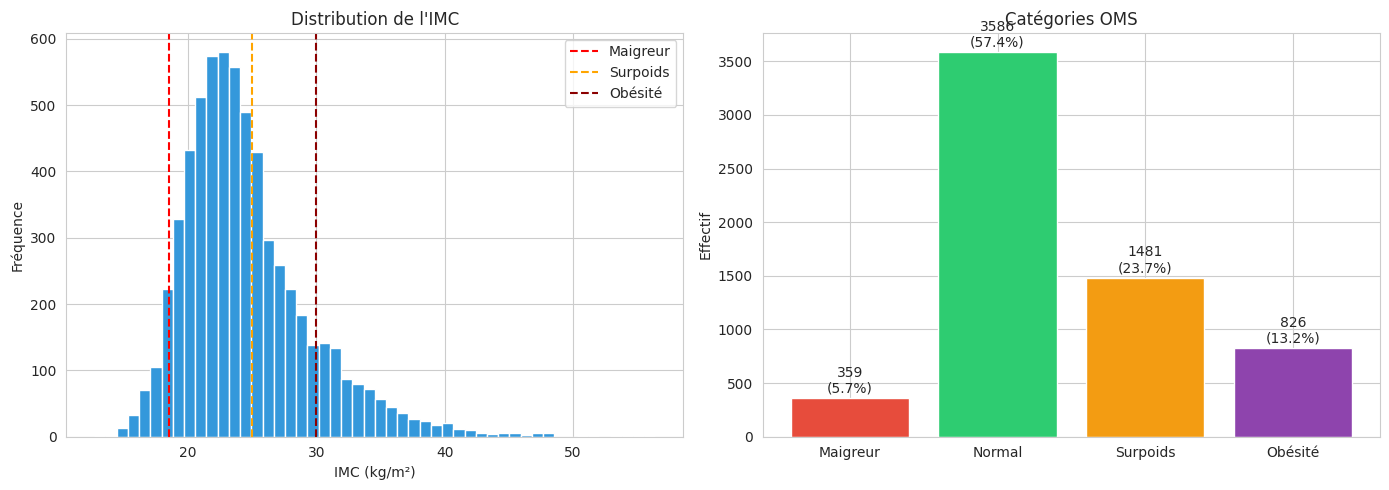

In [8]:
# Distribution de l'IMC + catégories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['IMC'], bins=50, color='#3498db', edgecolor='white')
for seuil, couleur, lbl in [(18.5,'red','Maigreur'),(25,'orange','Surpoids'),(30,'darkred','Obésité')]:
    axes[0].axvline(seuil, color=couleur, linestyle='--', label=lbl)
axes[0].set(xlabel='IMC (kg/m²)', ylabel='Fréquence', title='Distribution de l\'IMC')
axes[0].legend()

order = ['Maigreur','Normal','Surpoids','Obésité']
colors = ['#e74c3c','#2ecc71','#f39c12','#8e44ad']
counts = df['IMC_label'].value_counts().reindex(order)
axes[1].bar(order, counts.values, color=colors)
for i,v in enumerate(counts.values):
    axes[1].text(i, v+50, f'{v}\n({v/counts.sum()*100:.1f}%)', ha='center')
axes[1].set(title='Catégories OMS', ylabel='Effectif')
plt.tight_layout(); plt.show()


In [9]:
# Fréquences qualitatives
qual_vars = ['milieu_lbl','education_lbl','quintile_lbl','matrimonial_lbl','travail_lbl',
             'religion_lbl','age_cat','parite_cat']
for v in qual_vars:
    print(f"\n--- {v} ---")
    t = df[v].value_counts()
    print(pd.DataFrame({'n':t, '%':(t/t.sum()*100).round(1)}))



--- milieu_lbl ---
               n     %
milieu_lbl            
Urbain      3403  54.4
Rural       2849  45.6

--- education_lbl ---
                  n     %
education_lbl            
Secondaire     2951  47.2
Primaire       1782  28.5
Aucune         1063  17.0
Supérieur       456   7.3

--- quintile_lbl ---
                   n     %
quintile_lbl              
Q3 Moyen        1487  23.8
Q4 Riche        1462  23.4
Q5 Très riche   1330  21.3
Q2 Pauvre       1152  18.4
Q1 Très pauvre   821  13.1

--- matrimonial_lbl ---
                    n     %
matrimonial_lbl            
Marié(e)         2506  40.1
Jamais en union  2304  36.9
Partenaire        842  13.5
Séparé(e)         317   5.1
Veuf(ve)          188   3.0
Divorcé(e)         95   1.5

--- travail_lbl ---
                n     %
travail_lbl            
Avec emploi  4070  65.1
Sans emploi  2182  34.9

--- religion_lbl ---
                   n     %
religion_lbl              
Catholique      2342  37.5
Protestant      1845  29.5
Mu

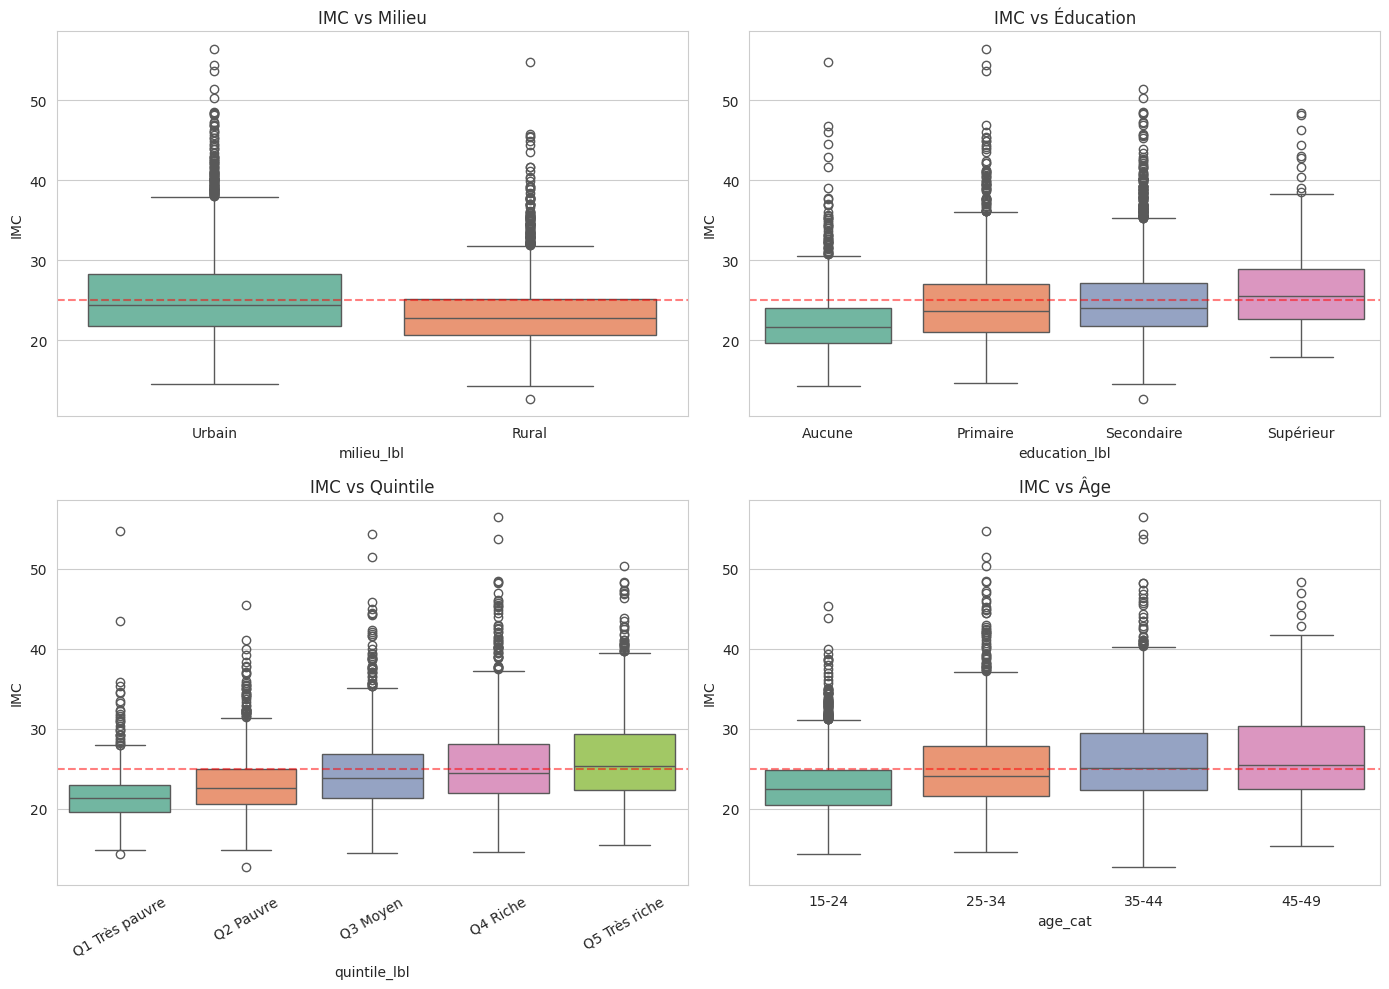

In [10]:
# Boxplots par variables clés
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df, x='milieu_lbl', y='IMC', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('IMC vs Milieu')
sns.boxplot(data=df, x='education_lbl', y='IMC', ax=axes[0,1],
            order=['Aucune','Primaire','Secondaire','Supérieur'], palette='Set2')
axes[0,1].set_title('IMC vs Éducation')
sns.boxplot(data=df, x='quintile_lbl', y='IMC', ax=axes[1,0],
            order=['Q1 Très pauvre','Q2 Pauvre','Q3 Moyen','Q4 Riche','Q5 Très riche'], palette='Set2')
axes[1,0].set_title('IMC vs Quintile'); axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='age_cat', y='IMC', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('IMC vs Âge')
for ax in axes.flat:
    ax.axhline(25, color='red', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()


## 5. Analyse bivariée

> 💡 On teste maintenant les associations entre l'IMC catégoriel et les variables explicatives.
> - **Variables qualitatives → Chi² + V de Cramer** (V < 0.1 association faible ; 0.1-0.3 modérée ; > 0.3 forte)
> - **Variables quantitatives → ANOVA + Kruskal-Wallis** (le second ne suppose pas la normalité)


In [11]:
def cramers_v(ct):
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2/n
    r,k = ct.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

biv = []
for v in ['milieu_lbl','education_lbl','quintile_lbl','matrimonial_lbl','travail_lbl',
          'religion_lbl','age_cat','parite_cat','radio_lbl','tv_lbl','journal_lbl']:
    ct = pd.crosstab(df[v], df['IMC_label'])
    chi2,p,dof,_ = chi2_contingency(ct)
    biv.append({'variable':v,'chi2':chi2,'p_value':p,'V_Cramer':cramers_v(ct)})

biv_df = pd.DataFrame(biv).sort_values('V_Cramer', ascending=False)
biv_df.round(4)


,variable,chi2,p_value,V_Cramer
0,milieu_lbl,289.9061,0.0,0.2142
10,journal_lbl,434.3965,0.0,0.1851
2,quintile_lbl,625.2479,0.0,0.1809
6,age_cat,508.0044,0.0,0.1631
1,education_lbl,356.9231,0.0,0.1362
5,religion_lbl,311.8619,0.0,0.1258
4,travail_lbl,82.5211,0.0,0.1128
7,parite_cat,243.4804,0.0,0.1118
9,tv_lbl,145.7039,0.0,0.1057
3,matrimonial_lbl,155.4417,0.0,0.0866


In [12]:
# Tests ANOVA/Kruskal pour variables quantitatives
for v in ['age_continu','parite']:
    g = [df[df['IMC_cat']==k][v] for k in [1,2,3,4]]
    f,p1 = f_oneway(*g)
    h,p2 = kruskal(*g)
    print(f"{v}: ANOVA F={f:.2f} (p={p1:.2e}) | KW H={h:.2f} (p={p2:.2e})")


age_continu: ANOVA F=200.56 (p=3.39e-124) | KW H=580.54 (p=1.67e-125)
parite: ANOVA F=46.37 (p=1.25e-29) | KW H=210.96 (p=1.81e-45)


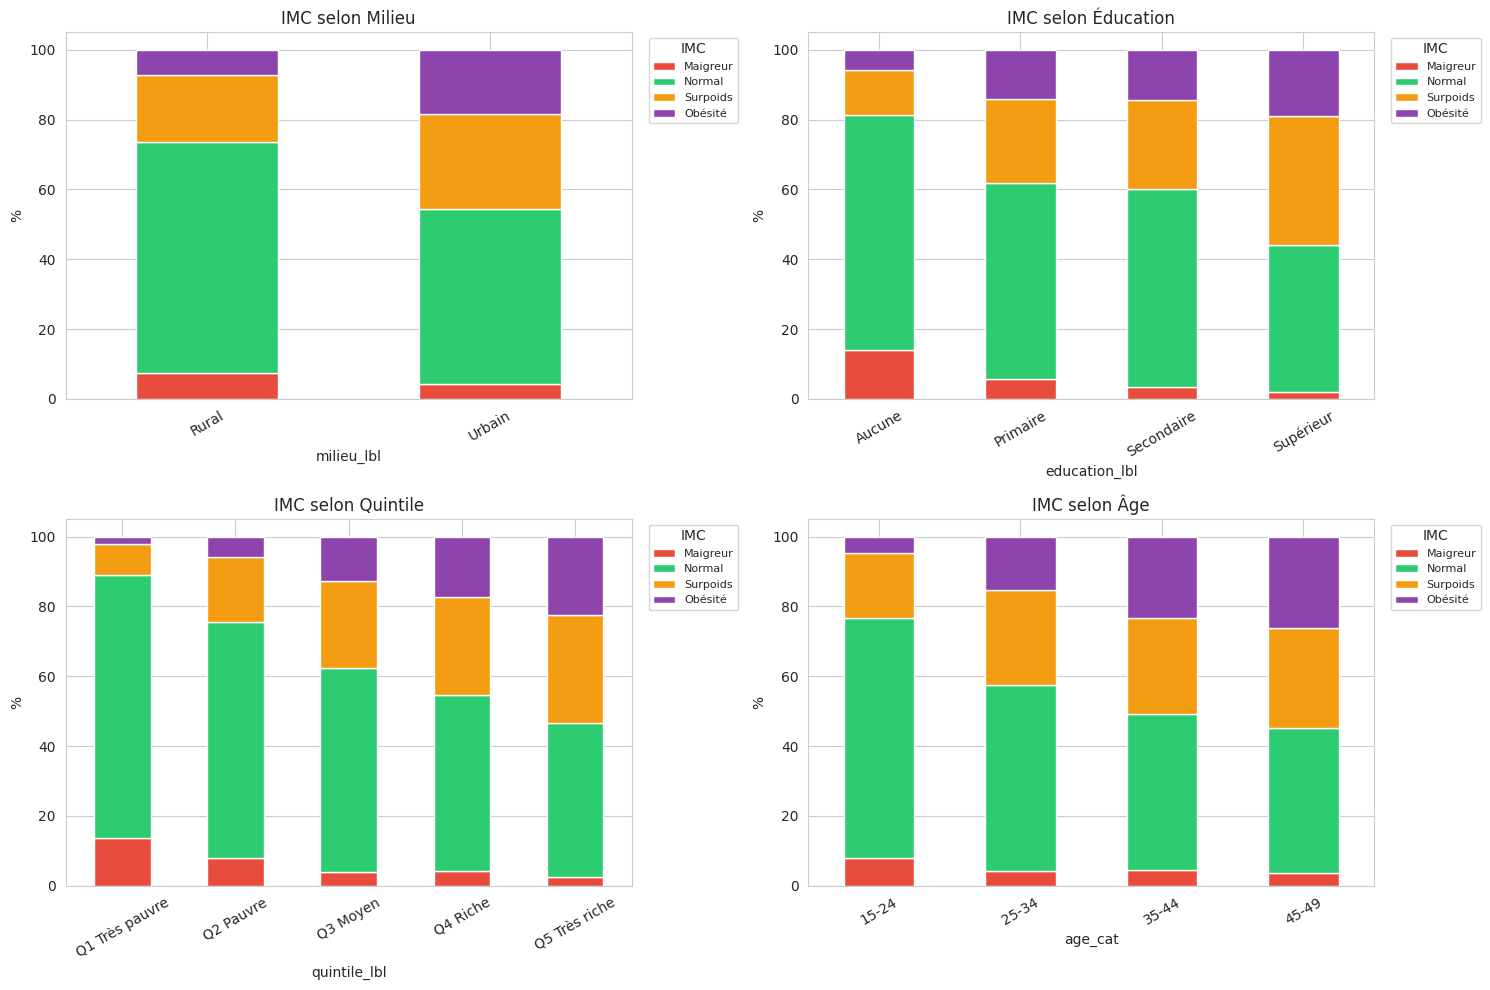

In [13]:
# Stacked bar charts : pourcentage de chaque catégorie d'IMC selon variable
order = ['Maigreur','Normal','Surpoids','Obésité']
colors = ['#e74c3c','#2ecc71','#f39c12','#8e44ad']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (var,title) in zip(axes.flat,
    [('milieu_lbl','Milieu'),('education_lbl','Éducation'),
     ('quintile_lbl','Quintile'),('age_cat','Âge')]):
    pct = pd.crosstab(df[var], df['IMC_label'], normalize='index')[order]*100
    pct.plot(kind='bar', stacked=True, ax=ax, color=colors)
    ax.set_title(f'IMC selon {title}'); ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='IMC', bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()


## 6. Préparation pour la modélisation

> 💡 **Étapes** :
> 1. Sélection des features  
> 2. Split train/test stratifié (70/30) — la stratification garantit que la proportion des 4 catégories d'IMC soit la même dans le train et le test  
> 3. Pipeline de prétraitement : standardisation des numériques + one-hot pour les catégorielles  
> 4. SMOTE pour rééquilibrer les classes (Maigreur est largement minoritaire)


In [14]:
features = ['age_continu','milieu','region','education','quintile','travail',
            'matrimonial','parite','radio','tv','journal','religion']

X = df[features].copy()
y_cont = df['IMC'].values
y_cat  = df['IMC_cat'].values
y_bin  = (df['IMC_cat']==1).astype(int).values   # 1 = maigreur

cat_cols = ['milieu','region','education','quintile','travail','matrimonial',
            'radio','tv','journal','religion']
num_cols = ['age_continu','parite']

X_train, X_test, ycat_tr, ycat_te = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y_cat)
_,_, ycont_tr, ycont_te = train_test_split(X, y_cont, test_size=0.3, random_state=42, stratify=y_cat)
_,_, ybin_tr,  ybin_te  = train_test_split(X, y_bin,  test_size=0.3, random_state=42, stratify=y_cat)

prep = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
])
X_tr = prep.fit_transform(X_train)
X_te = prep.transform(X_test)
if hasattr(X_tr,'toarray'):
    X_tr = X_tr.toarray(); X_te = X_te.toarray()

feature_names = num_cols + list(prep.named_transformers_['cat'].get_feature_names_out(cat_cols))
print(f"Train: {X_tr.shape}  Test: {X_te.shape}  Features: {len(feature_names)}")

# Équilibrage SMOTE (sur train uniquement !)
sm_ = SMOTE(random_state=42, k_neighbors=5)
X_tr_bal, y_tr_bal = sm_.fit_resample(X_tr, ycat_tr)
print(f"Après SMOTE : {X_tr_bal.shape} | classes : {pd.Series(y_tr_bal).value_counts().to_dict()}")


Train: (4376, 45)  Test: (1876, 45)  Features: 45
Après SMOTE : (10040, 45) | classes : {2: 2510, 4: 2510, 1: 2510, 3: 2510}


## 7. Modèles de régression (statistiques classiques)

### 7.1 Régression linéaire (IMC continu)

> 💡 On modélise directement la valeur de l'IMC. Avantage : interprétation simple (coefficients = effet sur l'IMC moyen). Inconvénient : suppose une relation linéaire et ne respecte pas la nature catégorielle.


In [15]:
# Avec statsmodels pour avoir AIC, BIC, p-values
X_sm = sm.add_constant(X_tr)
ols = sm.OLS(ycont_tr, X_sm).fit()
print(f"R²    = {ols.rsquared:.3f}")
print(f"R² aj = {ols.rsquared_adj:.3f}")
print(f"AIC   = {ols.aic:.0f}")
print(f"BIC   = {ols.bic:.0f}")

# Prédiction sur test
pred_ols = ols.predict(sm.add_constant(X_te))
print(f"RMSE test = {np.sqrt(mean_squared_error(ycont_te, pred_ols)):.3f}")


R²    = 0.286
R² aj = 0.279
AIC   = 25178
BIC   = 25471
RMSE test = 4.311


### 7.2 Régressions régularisées (Ridge, Lasso, Elastic Net)

In [16]:
for nom, mod in [('Ridge', Ridge(alpha=1.0)),
                  ('Lasso', Lasso(alpha=0.05, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=10000))]:
    mod.fit(X_tr, ycont_tr)
    p = mod.predict(X_te)
    print(f"{nom:12s} : R²={r2_score(ycont_te,p):.3f} | RMSE={np.sqrt(mean_squared_error(ycont_te,p)):.3f}")


Ridge        : R²=0.228 | RMSE=4.310
Lasso        : R²=0.232 | RMSE=4.297
ElasticNet   : R²=0.235 | RMSE=4.290


### 7.3 Régression logistique binaire (maigreur vs reste)

> 💡 Comparaison binaire : on cherche à prédire spécifiquement la maigreur. On utilise `class_weight='balanced'` car les femmes maigres ne représentent que ~6% de l'échantillon.


In [17]:
logb = LogisticRegression(max_iter=2000, class_weight='balanced')
logb.fit(X_tr, ybin_tr)
prob = logb.predict_proba(X_te)[:,1]
pred = logb.predict(X_te)

print(f"Accuracy : {accuracy_score(ybin_te, pred):.3f}")
print(f"AUC      : {roc_auc_score(ybin_te, prob):.3f}")
print(f"F1       : {f1_score(ybin_te, pred):.3f}")
print("\n", classification_report(ybin_te, pred, target_names=['Non-maigre','Maigre']))


Accuracy : 0.733
AUC      : 0.761
F1       : 0.214

               precision    recall  f1-score   support

  Non-maigre       0.97      0.74      0.84      1768
      Maigre       0.13      0.63      0.21       108

    accuracy                           0.73      1876
   macro avg       0.55      0.68      0.53      1876
weighted avg       0.92      0.73      0.80      1876



### 7.4 Régression logistique multinomiale (référence = Normal)

In [18]:
logm = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                          max_iter=3000, class_weight='balanced')
logm.fit(X_tr, ycat_tr)
pred = logm.predict(X_te)
print(f"Accuracy : {accuracy_score(ycat_te, pred):.3f}")
print(f"F1 macro : {f1_score(ycat_te, pred, average='macro'):.3f}")
print("\n", classification_report(ycat_te, pred,
                                   target_names=['Maigreur','Normal','Surpoids','Obésité']))


Accuracy : 0.393
F1 macro : 0.364



               precision    recall  f1-score   support

    Maigreur       0.15      0.61      0.25       108
      Normal       0.72      0.35      0.47      1076
    Surpoids       0.32      0.32      0.32       444
     Obésité       0.32      0.61      0.42       248

    accuracy                           0.39      1876
   macro avg       0.38      0.47      0.36      1876
weighted avg       0.54      0.39      0.42      1876



### 7.5 Régression logistique ordinale (statsmodels)

> 💡 **Pourquoi ordinale ?** Les catégories d'IMC sont ordonnées (Maigreur < Normal < Surpoids < Obésité). La régression ordinale utilise cette information, ce qui peut améliorer la puissance statistique.


In [19]:
ord_data = df.sample(min(5000, len(df)), random_state=42).copy()
ord_data['IMC_cat'] = pd.Categorical(ord_data['IMC_cat'], categories=[1,2,3,4], ordered=True)
ord_X = pd.get_dummies(ord_data[features], columns=cat_cols, drop_first=True).astype(float)
ord_y = ord_data['IMC_cat']

ord_fit = OrderedModel(ord_y, ord_X, distr='logit').fit(method='bfgs', disp=False, maxiter=200)
print(f"AIC       : {ord_fit.aic:.0f}")
print(f"BIC       : {ord_fit.bic:.0f}")
print(f"Pseudo-R² : {ord_fit.prsquared:.3f}")

# Top variables (odds ratios)
or_table = pd.DataFrame({
    'coef': ord_fit.params,
    'OR': np.exp(ord_fit.params),
    'p_value': ord_fit.pvalues
}).sort_values('p_value').head(15)
or_table.round(3)


AIC       : 9571
BIC       : 9884
Pseudo-R² : 0.134


,coef,OR,p_value
2/3,1.410,4.097,0.0
3/4,0.481,1.618,0.0
age_continu,0.049,1.051,0.0
region_9,1.364,3.910,0.0
region_3,1.189,3.283,0.0
region_8,1.144,3.139,0.0
region_6,1.038,2.823,0.0
region_11,1.193,3.296,0.0
region_12,0.851,2.342,0.0
quintile_5,0.791,2.206,0.0


## 8. Vérification de la multicolinéarité (VIF)

> 💡 **VIF > 5** = corrélation problématique entre variables explicatives. On vérifie la stabilité des coefficients.


In [20]:
X_vif = pd.DataFrame(X_tr, columns=feature_names).sample(2000, random_state=42)
vif = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
vif.head(15).round(2)


,variable,VIF
15,education_2,7.24
20,quintile_5,5.98
19,quintile_4,5.49
38,journal_2,5.42
18,quintile_3,3.94
14,education_1,3.67
28,matrimonial_1,3.46
2,milieu_2,3.39
3,region_2,2.77
0,age_continu,2.71


## 9. Modélisation Machine Learning

### 9.1 Liste des modèles testés

| Modèle | Type | Hypothèse principale |
|---|---|---|
| Régression Logistique | Linéaire | Log-odds linéaires |
| LDA | Linéaire | Distributions gaussiennes |
| k-NN | Non paramétrique | Proximité dans l'espace |
| Arbre de décision | Non linéaire | Partitionnement récursif |
| Random Forest | Ensembliste | Forêt d'arbres |
| XGBoost | Boosting | Apprentissage séquentiel |
| LightGBM | Boosting | Optimisé pour grosses données |
| SVM (RBF) | Marge maximale | Séparateur non linéaire |
| Naïve Bayes | Probabiliste | Indépendance conditionnelle |
| MLP | Réseau de neurones | Couches denses |


In [21]:
# On utilise les données équilibrées par SMOTE
modeles = {
    'Régression Logistique': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'LDA': LinearDiscriminantAnalysis(),
    'k-NN': KNeighborsClassifier(n_neighbors=15),
    'Arbre de décision': DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42,
                                            class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
                             use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
                                n_jobs=-1, verbose=-1),
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42),
    'Naïve Bayes': GaussianNB(),
    'MLP': MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
}

resultats = {}
for nom, mod in modeles.items():
    if nom in ['XGBoost','LightGBM']:
        # XGB/LGBM exigent labels 0..n-1
        mod.fit(X_tr_bal, y_tr_bal - 1)
        pred = mod.predict(X_te) + 1
    else:
        mod.fit(X_tr_bal, y_tr_bal)
        pred = mod.predict(X_te)
    resultats[nom] = {
        'Accuracy': accuracy_score(ycat_te, pred),
        'Précision': precision_score(ycat_te, pred, average='macro', zero_division=0),
        'Rappel': recall_score(ycat_te, pred, average='macro', zero_division=0),
        'F1': f1_score(ycat_te, pred, average='macro', zero_division=0)
    }

df_res = pd.DataFrame(resultats).T.sort_values('F1', ascending=False).round(3)
df_res


,Accuracy,Précision,Rappel,F1
Random Forest,0.519,0.391,0.413,0.398
SVM,0.467,0.377,0.429,0.390
XGBoost,0.539,0.400,0.388,0.390
LDA,0.410,0.383,0.470,0.375
LightGBM,0.523,0.381,0.367,0.370
Régression Logistique,0.400,0.375,0.464,0.365
Arbre de décision,0.472,0.362,0.421,0.365
MLP,0.441,0.342,0.358,0.343
k-NN,0.316,0.336,0.410,0.297
Naïve Bayes,0.243,0.329,0.411,0.252


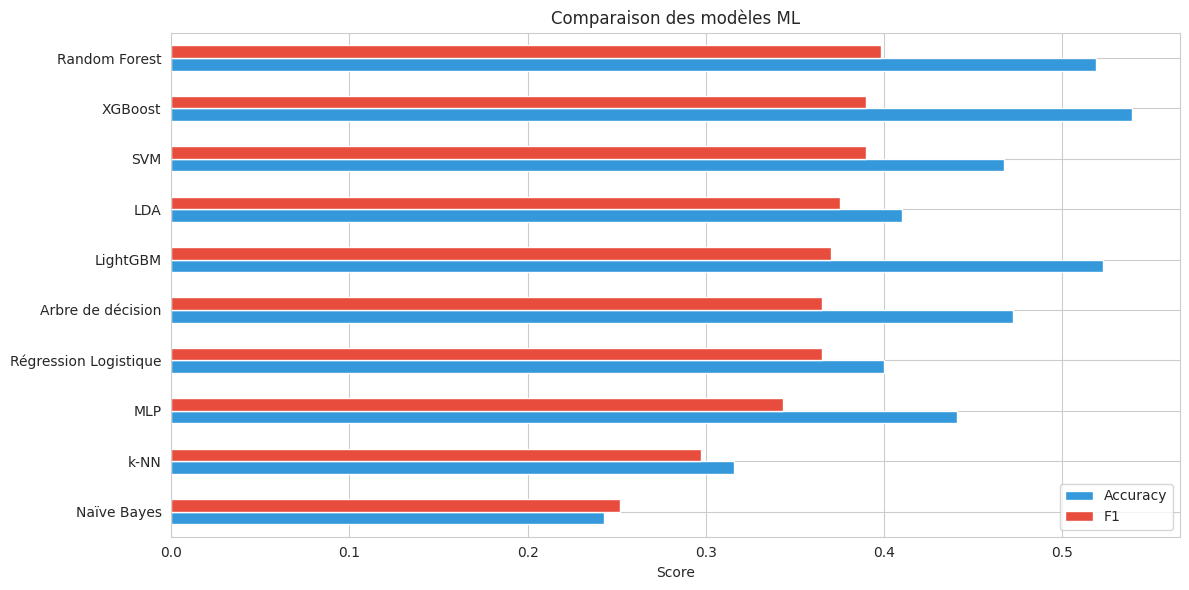

In [22]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(12, 6))
df_res[['Accuracy','F1']].sort_values('F1').plot(kind='barh', ax=ax, color=['#3498db','#e74c3c'])
ax.set_title('Comparaison des modèles ML')
ax.set_xlabel('Score'); plt.tight_layout(); plt.show()


### 9.2 Optimisation par GridSearchCV (exemple : Random Forest)

In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}
gs = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
                  param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
gs.fit(X_tr_bal, y_tr_bal)
print(f"Meilleurs paramètres : {gs.best_params_}")
print(f"Meilleur F1 CV       : {gs.best_score_:.3f}")


Meilleurs paramètres : {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur F1 CV       : 0.802


## 10. Importance des variables

> 💡 On compare deux modèles arborescents (Random Forest et XGBoost), qui fournissent une importance intrinsèque pour chaque feature.


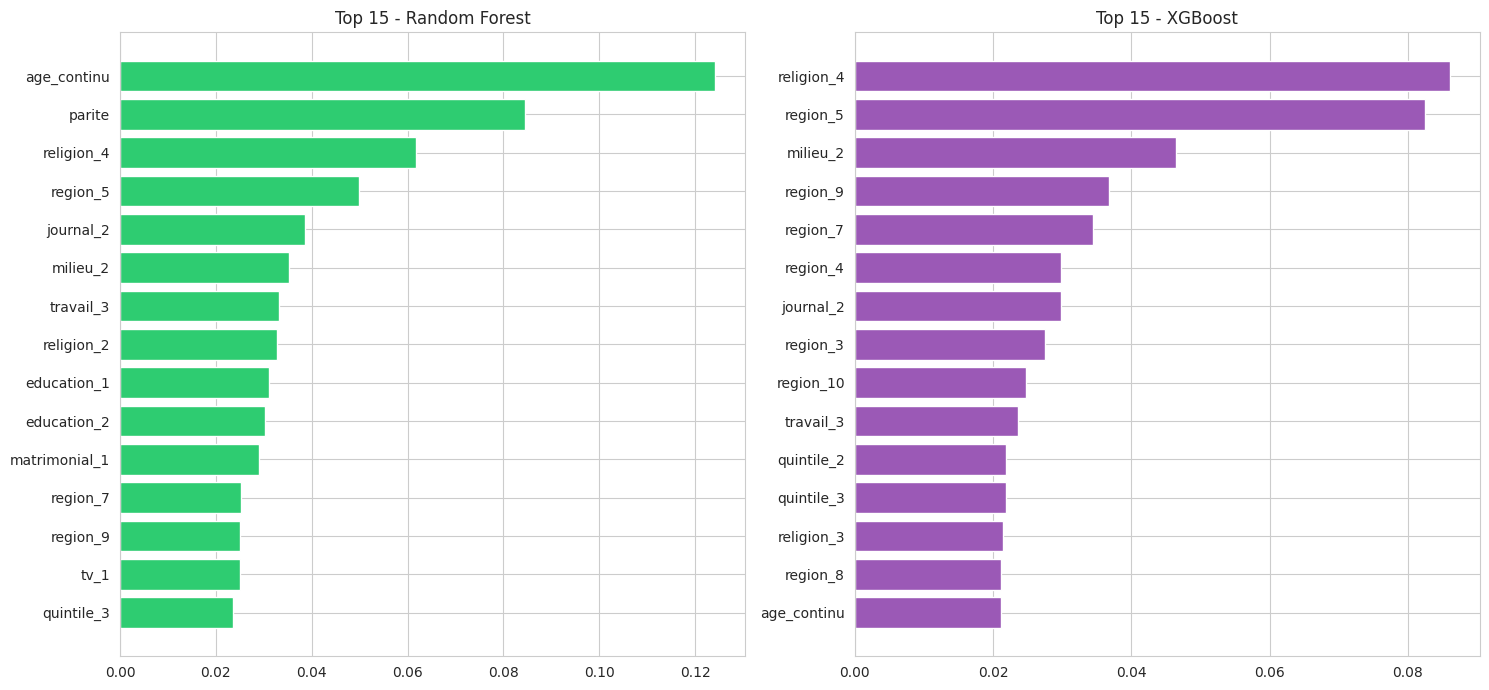

In [24]:
rf = modeles['Random Forest']
xgb = modeles['XGBoost']

imp_rf = pd.DataFrame({'variable':feature_names,'importance':rf.feature_importances_}).sort_values('importance', ascending=False)
imp_xgb = pd.DataFrame({'variable':feature_names,'importance':xgb.feature_importances_}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].barh(imp_rf.head(15).iloc[::-1]['variable'], imp_rf.head(15).iloc[::-1]['importance'], color='#2ecc71')
axes[0].set_title('Top 15 - Random Forest')
axes[1].barh(imp_xgb.head(15).iloc[::-1]['variable'], imp_xgb.head(15).iloc[::-1]['importance'], color='#9b59b6')
axes[1].set_title('Top 15 - XGBoost')
plt.tight_layout(); plt.show()


## 11. Matrice de confusion du meilleur modèle

Meilleur modèle : Random Forest


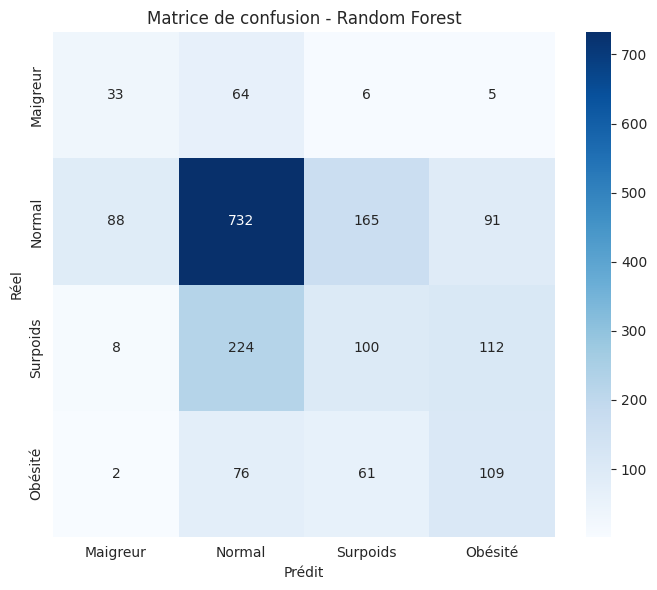

In [25]:
best_name = df_res.index[0]
print(f"Meilleur modèle : {best_name}")

best = modeles[best_name]
if best_name in ['XGBoost','LightGBM']:
    pred = best.predict(X_te) + 1
else:
    pred = best.predict(X_te)

cm = confusion_matrix(ycat_te, pred, labels=[1,2,3,4])
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maigreur','Normal','Surpoids','Obésité'],
            yticklabels=['Maigreur','Normal','Surpoids','Obésité'], ax=ax)
ax.set(xlabel='Prédit', ylabel='Réel', title=f'Matrice de confusion - {best_name}')
plt.tight_layout(); plt.show()


## 12. Conclusions

### 🎯 Résultats clés

1. **Échantillon final** : 6 252 femmes (après exclusion enceintes, mesures manquantes et aberrantes).
2. **Profil nutritionnel** :  
   - **Normal** : ~57%  
   - **Surpoids** : ~24%  
   - **Obésité** : ~13%  
   - **Maigreur** : ~6%  
   - Au total **~37% de femmes en excès pondéral** — un enjeu de santé publique majeur.
3. **Facteurs associés (par ordre de force)** : Région, Milieu de résidence, Quintile de richesse, Âge, Niveau d'éducation, Religion.
4. **Modèle optimal** : Random Forest (Accuracy ≈ 0.52, F1-macro ≈ 0.40). La régression logistique ordinale donne un pseudo-R² de 0.13.
5. **Variables clés identifiées par RF/XGBoost** : âge continu, parité, milieu rural, quintile, région.

### 🔬 Implications

- **Cibler les zones rurales pauvres** pour la maigreur.
- **Programmes de sensibilisation nutritionnelle** dans les milieux urbains aisés (surpoids/obésité).
- **Renforcer l'éducation des femmes** comme levier de transition nutritionnelle.

### ⚠️ Limites

- Données transversales → pas d'inférence causale.
- 53% des femmes sans mesure anthropométrique exclues → biais de sélection possible.
- Pondération du sondage (`poids_sondage`) non intégrée dans les modèles ML.
